In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict , Literal

In [2]:
# create state
class equationState(TypedDict):
    a: int
    b: int
    c: int


    equation: str # store equation
    descriminent : float # store descriminent
    result: str  # store result

In [5]:
def show_equation(state:equationState):
    a = state['a']
    b = state['b']
    c = state['c']

    equation = f'{a}x2 + {b}x + {c}'
    return {
        'equation' : equation}



In [4]:
def show_descriminent(state:equationState):
    descriminant = (state['b']**2 - 4*state['a']*state['c'])
    return {'descriminent':descriminant}

In [14]:
def real_root(state:equationState):
    root1 = (-state['b'] + state['descriminent']**0.5)/ 2 * state['a']
    root2 = (-state['b'] - state['descriminent']**0.5)/ 2 * state['a']

    result = f'the roots are {root1} and {root2}'
    return {
        'result' : result
    }

def repeated_root(state:equationState):
        root = (-state['b']  / 2 * state['a'])
        result = f' the repeating root is {root}'
        return {
              'result' : result
        }

def no_real_root(state:equationState):
    result = f'No real roots'
    return {
              'result' : result
        }
      
def check_condition(state:equationState)-> Literal['real_root', 'repeated_root', 'no_real_root']:
     if state['descriminent'] > 0:
       return 'real_root'
     elif state['descriminent'] ==0:
          return 'repeated_root'
     else:
          return 'no_real_root'
       


In [ ]:
graph = StateGraph(equationState)

# add node
graph.add_node('show_equation', show_equation)
graph.add_node('show_descriminent', show_descriminent)
graph.add_node('real_root', real_root)
graph.add_node('repeated_root', repeated_root)
graph.add_node('no_real_root',no_real_root)

# add edges 
graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','show_descriminent')

graph.add_conditional_edges('show_descriminent', check_condition)
graph.add_edge('real_root',END)
graph.add_edge('repeated_root',END)
graph.add_edge('no_real_root',END)

graph.add_edge('show_descriminent', END)



workflow = graph.compile()





In [11]:
initial_state = {
    'a': 4,
    'b':-5,
    'c': -4
}

res = workflow.invoke(initial_state)

In [12]:
res

{'a': 4, 'b': -5, 'c': -4, 'equation': '4x2 + -5x + -4', 'descriminent': 89}

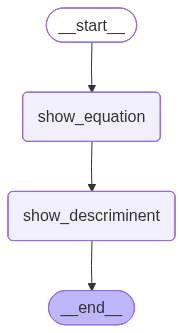

In [8]:
workflow